<p style="align: center;"><img align=center src="https://drive.google.com/uc?export=view&id=1TRNaCfYstvcIQqoUSdukYQGF6LuyL7Tv" width=600 height=320/></p>
<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

# Домашнее задание. Автоэнкодеры


# Часть 1. Vanilla Autoencoder (10 баллов)

## 1.1. Подготовка данных (1 балл)


In [62]:
import numpy as np
from sklearn.model_selection import train_test_split
from torch.autograd import Variable
import torchvision
from torchvision import datasets
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data_utils
import torch
import matplotlib.pyplot as plt
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from tqdm.auto import tqdm

import os
import random
import pandas as pd
import skimage.io
from skimage.transform import resize




%matplotlib inline

In [2]:
# Download some attributes

!gdown --id 1utdTz3TY2LyqoRHzZJVVeiku44pacQ0Y

/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1utdTz3TY2LyqoRHzZJVVeiku44pacQ0Y
To: /content/lfw_attributes.txt
100% 14.9M/14.9M [00:00<00:00, 113MB/s] 


In [3]:
!pip install kaggle # Установка библиотеки Kaggle

In [9]:
!mkdir ~/.kaggle # Создание каталога с именем “.kaggle”

mkdir: cannot create directory ‘/root/.kaggle’: File exists


In [10]:
!cp kaggle.json ~/.kaggle/ # Скопировать файл “kaggle.json” в созданный каталог

In [11]:
!chmod 600 ~/.kaggle/kaggle.json # Назначить необходимое разрешение для этого файла

In [12]:
# Remove the corrupted file
!rm -f /content/lfw-dataset.zip
# Re-download the dataset
!kaggle datasets download -d jessicali9530/lfw-dataset -p /content

Dataset URL: https://www.kaggle.com/datasets/jessicali9530/lfw-dataset
License(s): other


In [13]:
import zipfile
import os

zip_path = "/content/lfw-dataset.zip"
extract_dir = "/content/lfw_dataset"

try:
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print("Extraction successful!")
except zipfile.BadZipFile as e:
    print(f"Error: {e}")


Extraction successful!


In [14]:
def fetch_dataset(attrs_name = "lfw_attributes.txt",
                      images_name = "lfw_dataset",
                      dx=80,dy=80,
                      dimx=64,dimy=64
    ):

    #download if not exists
    assert os.path.exists(images_name)

    #read attrs
    df_attrs = pd.read_csv("lfw_attributes.txt",sep='\t',skiprows=1,)
    df_attrs = pd.DataFrame(df_attrs.iloc[:,:-1].values, columns = df_attrs.columns[1:])


    #read photos
    photo_ids = []
    for dirpath, dirnames, filenames in os.walk(images_name):
        for fname in filenames:
            if fname.endswith(".jpg"):
                fpath = os.path.join(dirpath,fname)
                photo_id = fname[:-4].replace('_',' ').split()
                person_id = ' '.join(photo_id[:-1])
                photo_number = int(photo_id[-1])
                photo_ids.append({'person':person_id,'imagenum':photo_number,'photo_path':fpath})

    photo_ids = pd.DataFrame(photo_ids)
    # print(photo_ids)
    #mass-merge
    #(photos now have same order as attributes)
    df = pd.merge(df_attrs,photo_ids,on=('person','imagenum'))

    assert len(df)==len(df_attrs),"lost some data when merging dataframes"

    # print(df.shape)
    #image preprocessing
    all_photos =df['photo_path'].apply(skimage.io.imread)\
                                .apply(lambda img:img[dy:-dy,dx:-dx])\
                                .apply(lambda img: resize(img,[dimx,dimy]))

    all_photos = np.stack(all_photos.values)#.astype('uint8')
    all_attrs = df.drop(["photo_path","person","imagenum"],axis=1)

    return all_photos, all_attrs

In [15]:
# The following line fetches you two datasets: images, usable for autoencoder training and attributes.
# Those attributes will be required for the final part of the assignment (applying smiles), so please keep them in mind


data, attrs = fetch_dataset()


Разбейте выборку картинок на train и val, выведите несколько картинок в output, чтобы посмотреть, как они выглядят, и приведите картинки к тензорам pytorch, чтобы можно было скормить их сети:

In [32]:
SEED = 42

def seed_torch(seed):
  random.seed(seed)
  os.environ['PYTHONHASHSEED'] = str(seed)
  np.random.seed(seed)
  torch.manual_seed(seed)
  torch.cuda.manual_seed(seed)
  torch.cuda.manual_seed_all(seed) # if you are using multi-GPU.
  torch.backends.cudnn.benchmark = False
  torch.backends.cudnn.deterministic = True

seed_torch(SEED)

In [33]:
class MyDataset(Dataset):
    def __init__(self, data, transformer):
        self.data = data
        self.transformer = transformer

    def __len__(self):
        return len(self.data)

    def __getitem__(self, ind):
        img = self.transformer(self.data[ind])
        return img

In [34]:
def transformer():
    transform = transforms.Compose([
            transforms.ToTensor()
        ])
    return transform

In [35]:
train_img, val_img, train_attrs, val_attrs = train_test_split(data, attrs, train_size=0.9, shuffle=False, random_state=SEED)

train_dataset = MyDataset(train_img, transformer=transformer())
valid_dataset = MyDataset(val_img, transformer=transformer())

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(valid_dataset, batch_size=32)

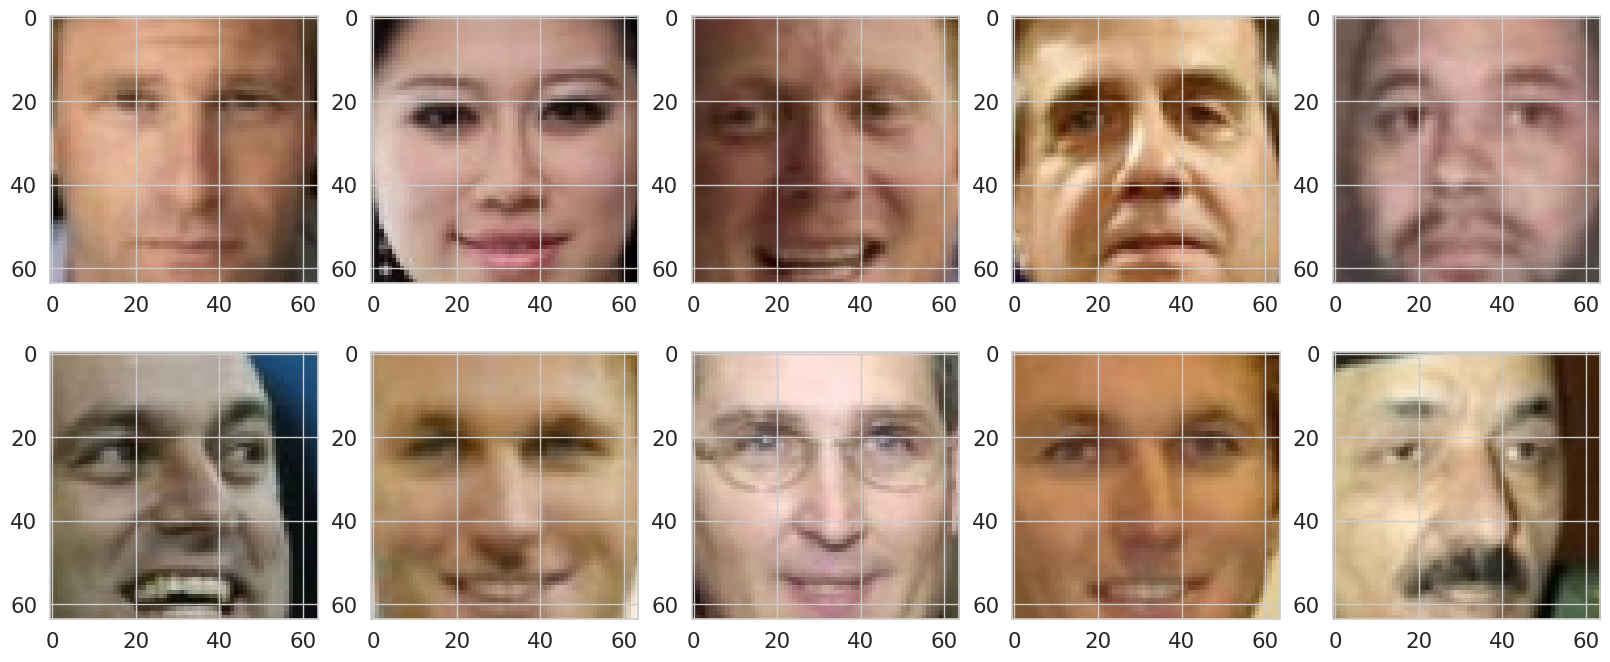

In [37]:
plt.figure(figsize=(20, 8))
for i, (gt, res) in enumerate(zip(train_img[:5], val_img[5:10])):
  plt.subplot(2, 5, 2*i+1)
  plt.imshow(gt)
  plt.subplot(2, 5, 2*i+2)
  plt.imshow(res)

## 1.2. Архитектура модели (2 балла)
В этом разделе мы напишем и обучем обычный автоэнкодер.

напомню, что автоэнкодер выглядит вот так:

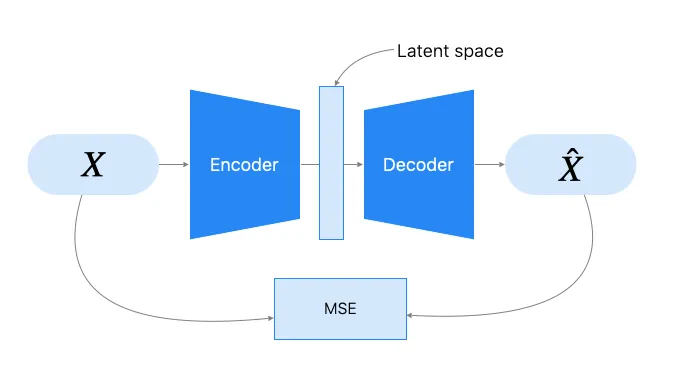

In [38]:
dim_code = 64 # выберите размер латентного вектора

Реализуем autoencoder. Архитектуру (conv, fully-connected, ReLu, etc) можете выбирать сами. Экспериментируйте!

In [39]:
'''
from copy import deepcopy

class Autoencoder(nn.Module):
    def __init__(self):
        <определите архитектуры encoder и decoder>
        # Обратите внимание на формат, в котором функция fetch() возвращает data

    def forward(self, x):

        <реализуйте forward проход автоэнкодера
        в качестве возвращаемых переменных -- латентное представление картинки (latent_code)
        и полученная реконструкция изображения (reconstruction)>

        return reconstruction, latent_code
'''

class MyAutoencoder(nn.Module):
    def __init__(self, dim_code:int=64):
        super().__init__()
        self.dim_code = dim_code
        self.flatten = nn.Flatten()

        # encoder
        self.encoder = nn.Sequential(
            nn.Linear(in_features=64*64*3, out_features=6144),
            nn.ReLU(),
            nn.BatchNorm1d(6144),
            nn.Dropout(0.4),
            nn.Linear(in_features=6144, out_features=3072),
            nn.ReLU(),
            nn.BatchNorm1d(3072),
            nn.Dropout(0.3),
            nn.Linear(in_features=3072, out_features=1024),
            nn.ReLU(),
            nn.BatchNorm1d(1024),
            nn.Dropout(0.2),
            nn.Linear(in_features=1024, out_features=512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.1),
            nn.Linear(in_features=512, out_features=self.dim_code)
        )

        # decoder
        self.decoder = nn.Sequential(
            nn.Linear(in_features=self.dim_code, out_features=512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.1),
            nn.Linear(in_features=512, out_features=1024),
            nn.ReLU(),
            nn.BatchNorm1d(1024),
            nn.Dropout(0.2),
            nn.Linear(in_features=1024, out_features=3072),
            nn.ReLU(),
            nn.BatchNorm1d(3072),
            nn.Dropout(0.3),
            nn.Linear(in_features=3072, out_features=6144),
            nn.ReLU(),
            nn.BatchNorm1d(6144),
            nn.Dropout(0.4),
            nn.Linear(in_features=6144, out_features=64*64*3)
        )

    def forward(self, x):
        # encoding
        x = x.reshape(-1, 64*64*3)
        latent = self.encoder(x)

        # decoding
        reconstruction = self.decoder(latent)
        reconstruction = reconstruction.view(-1, 3, 64, 64)
        return reconstruction, latent

    def sample(self, z):
        generated = self.decoder(z)
        generated = generated.view(-1, 3, 64, 64)
        return generated

In [40]:
# Отрисовка графиков обучения

def history_plot(history_loss):

    plt.figure(figsize=(12,6))
    plt.plot(history_loss['train'], label="train_loss",color='blue')
    plt.plot(history_loss['valid'], label="val_loss",color='orange')
    plt.legend(['train', 'valid'])
    plt.xlabel('epochs')
    plt.ylabel("loss")
    plt.grid()

    plt.show()

## 1.3 Обучение (2 балла)

Осталось написать код обучения автоэнкодера. При этом было бы неплохо в процессе иногда смотреть, как автоэнкодер реконструирует изображения на данном этапе обучения. Наример, после каждой эпохи (прогона train выборки через автоэекодер) можно смотреть, какие реконструкции получились для каких-то изображений val выборки.

А, ну еще было бы неплохо выводить графики train и val лоссов в процессе тренировки =)

In [41]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
SAVE = True
EPOCHS = 50

In [42]:
ae_model = MyAutoencoder().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(ae_model.parameters(), lr=3e-4)

ae_history_losses = {'train':[],'valid':[]}

for epoch in tqdm(range(EPOCHS)):
    ae_model.train()
    train_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()
        reconstruction,_ = ae_model(batch.float().to(device))
        loss = criterion(reconstruction, batch.float().to(device))
        loss.backward()
        optimizer.step()
        train_loss+=loss.item()
    ae_history_losses['train'].append(train_loss/len(train_loader))

    ae_model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            reconstruction, latent = ae_model(batch.float().to(device))
            loss = criterion(reconstruction, batch.float().to(device))
            val_loss+=loss.item()
        ae_history_losses['valid'].append(val_loss/len(val_loader))

    if epoch%2:
        gt = batch.cpu()[1].permute(1, 2, 0).detach().numpy()
        res = reconstruction.cpu()[1].permute(1, 2, 0).detach().numpy()
        plt.subplot(2, 2, 1)
        plt.imshow(gt)
        plt.subplot(2, 2, 2)
        plt.imshow(res)
        plt.suptitle(f'GROUND TRUTH vs RECONSTRUCTION')
        plt.show()

        print('EPOCH {}:'.format(epoch), "\n**TRAIN** loss:", train_loss/len(train_loader), "**EVAL** loss:",val_loss/len(val_loader),'\n','-'*150)

Output hidden; open in https://colab.research.google.com to view.

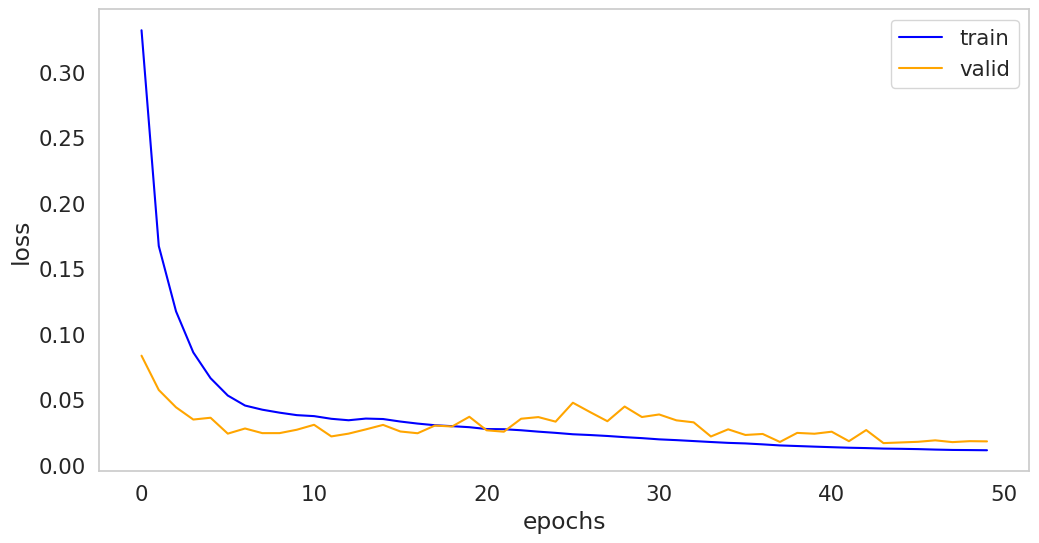

In [43]:
history_plot(ae_history_losses)

In [44]:
if SAVE:
    torch.save(ae_model.state_dict(), 'ae_model.pt')

Давайте посмотрим, как наш тренированный автоэекодер кодирует и восстанавливает картинки:

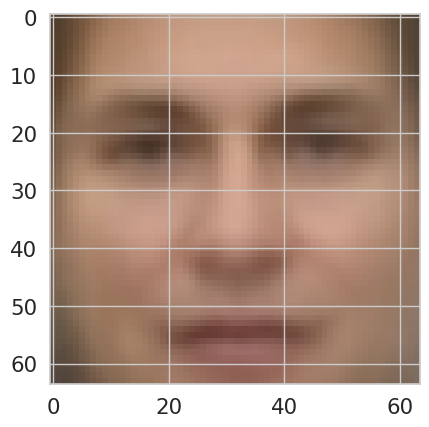

In [45]:
rand_img = np.random.normal(0, 1, size=(3, 64))
output = ae_model.sample(torch.FloatTensor(rand_img).to(device))
plt.imshow(output[0].permute(1,2,0).cpu().detach().numpy())
None

In [46]:
def compare(model, loader, n_out):

    x = next(iter(loader))
    model.eval()
    with torch.no_grad():
        res, _ = model(x.float().to(device))

    for i in range(n_out):
        plt.subplot(n_out*1, 2, 1)
        plt.imshow(x.cpu()[i].permute(1, 2, 0).detach().numpy())
        plt.subplot(n_out*1, 2, 2)
        plt.imshow(res.cpu()[i].permute(1, 2, 0).detach().numpy())
        plt.suptitle(f'GROUND TRUTH vs RECONSTRUCTION')
        plt.show()

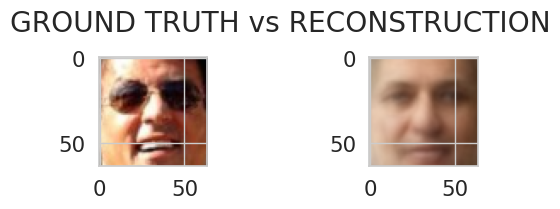

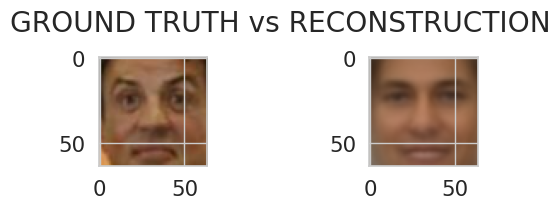

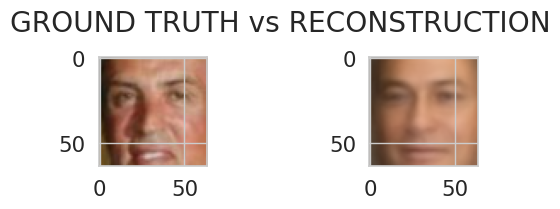

In [47]:
compare(ae_model, val_loader, 3)

Not bad, right?

## 1.4. Sampling (2 балла)

Давайте теперь будем не просто брать картинку, прогонять ее через автоэекодер и получать реконструкцию, а попробуем создать что-то НОВОЕ

Давайте возьмем и подсунем декодеру какие-нибудь сгенерированные нами векторы (например, из нормального распределения) и посмотрим на результат реконструкции декодера:

__Подсказка:__Е сли вместо лиц у вас выводится непонятно что, попробуйте посмотреть, как выглядят латентные векторы картинок из датасета. Так как в обучении нейронных сетей есть определенная доля рандома, векторы латентного слоя могут быть распределены НЕ как `np.random.randn(25, <latent_space_dim>)`. А чтобы у нас получались лица при запихивании вектора декодеру, вектор должен быть распределен так же, как латентные векторы реальных фоток. Так что в таком случае придется рандом немного подогнать.

In [48]:
latent_space = []
ae_model.eval()
with torch.no_grad():
    for batch in valid_dataset:
        reconstruction, latent = ae_model(batch.float().to(device))
        latent_space.append(latent)
total_space = latent_space[0].cpu().numpy()

# Сконкатинируем все латентные состояния
for i in range(len(latent_space)):
    total_space = np.concatenate((total_space, latent_space[i].cpu().numpy()))

# Найдем среднее и стандартное отклонение
mean_sp = np.mean(total_space, axis=0)
std_sp = np.std(total_space, axis=0)

<ipython-input-49-a5d6b278962c>:5: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:254.)
  out = ae_model.sample(torch.FloatTensor(randoms).to(device))


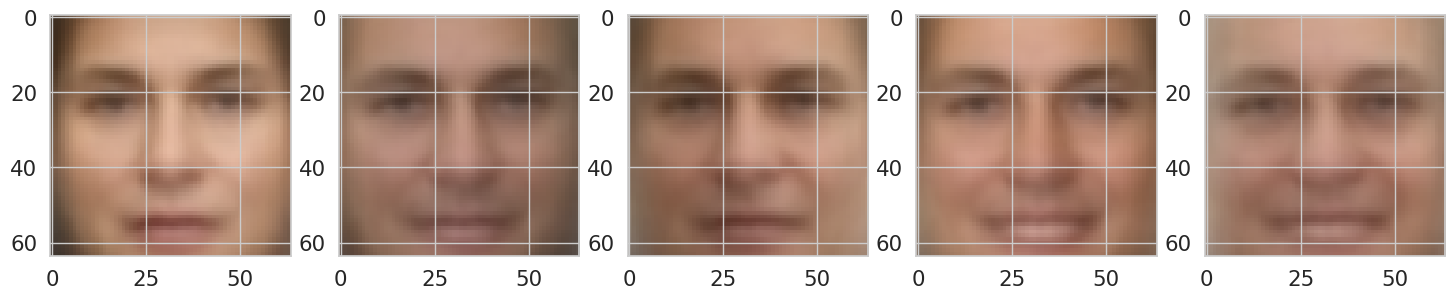

In [49]:
randoms = []
for mean, std in zip(mean_sp, std_sp):
    randoms.append(np.random.normal(mean.item(), std.item(), size=latent_space[0].size(1)))

out = ae_model.sample(torch.FloatTensor(randoms).to(device))
plt.figure(figsize=(18, 5))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(out[i].permute(1, 2, 0).cpu().detach().numpy())

## 1.5 Time to make fun! (3 балла)

Давайте научимся пририсовывать людям улыбки =)

<img src="https://i.imgur.com/tOE9rDK.png" alt="linear" width="700" height="400">

План такой:

1. Нужно выделить "вектор улыбки": для этого нужно из выборки изображений найти несколько (~15) людей с улыбками и столько же без.

Найти людей с улыбками вам поможет файл с описанием датасета, скачанный вместе с датасетом. В нем указаны имена картинок и присутствубщие атрибуты (улыбки, очки...)

2. Вычислить латентный вектор для всех улыбающихся людей (прогнать их через encoder) и то же для всех грустненьких

3. Вычислить, собственно, вектор улыбки -- посчитать разность между средним латентным вектором улыбающихся людей и средним латентным вектором грустных людей

4. А теперь приделаем улыбку грустному человеку: добавим полученный в пункте 3 вектор к латентному вектору грустного человека и прогоним полученный вектор через decoder. Получим того же человека, но уже не грустненького!

99


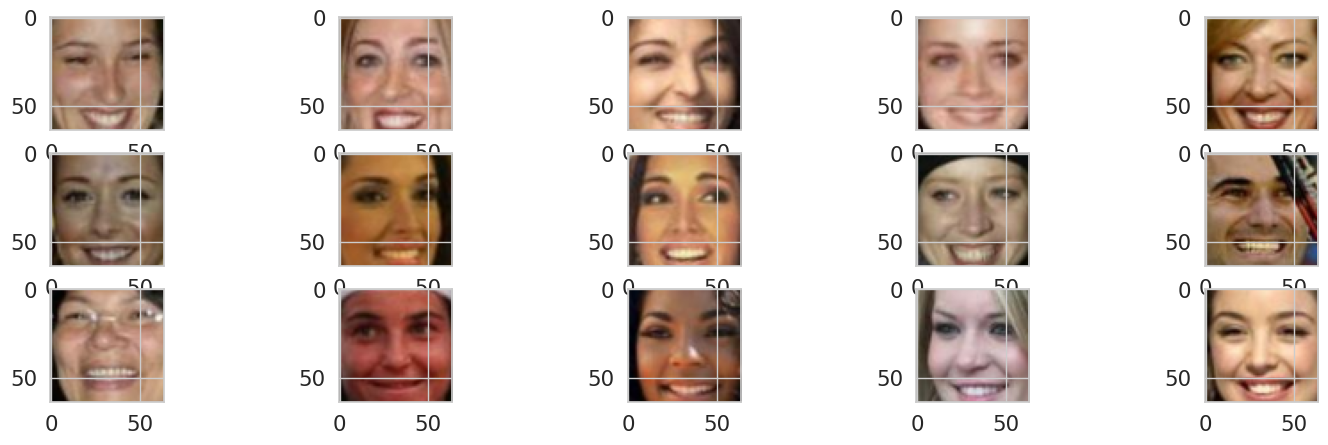

In [50]:
# Найдем фото с улыбкой:

smile_people = list(train_attrs[train_attrs.Smiling>2.3].index)
print(len(smile_people))

plt.figure(figsize=(18, 5))
a_smile = len(smile_people[:15])
for i in range(a_smile):
    plt.subplot(3, 5, i + 1)
    plt.imshow(train_img[smile_people[i]])

In [51]:
smile_latent_space = []
ae_model.eval()
with torch.no_grad():
    for idx in smile_people:
        image = torch.FloatTensor(train_img[idx]).permute(2, 0, 1)
        reconstructed, latent_code = ae_model(image.to(device))
        smile_latent_space.append(latent_code)

smile_total_space = smile_latent_space[0].cpu().numpy()

# Сконкатинируем все латентные состояния улыбающихся людей
for i in range(len(smile_latent_space)):
    smile_total_space = np.concatenate((smile_total_space, smile_latent_space[i].cpu().numpy()))

# Найдем среднее и стандартное отклонение
mean_smile_sp = np.mean(smile_total_space, axis=0)
std_smile_sp = np.std(smile_total_space, axis=0)

In [52]:
smile_randoms = []
for mean, std in zip(mean_smile_sp, std_smile_sp):
    smile_randoms.append(np.random.normal(mean.item(), std.item(), size=smile_latent_space[0].size(1)))

#out = ae_model.sample(torch.FloatTensor(smile_randoms).to(device))
#plt.figure(figsize=(18, 5))
#for i in range(5):
#    plt.subplot(1, 5, i + 1)
#    plt.imshow(out[i].permute(1, 2, 0).cpu().detach().numpy())

46


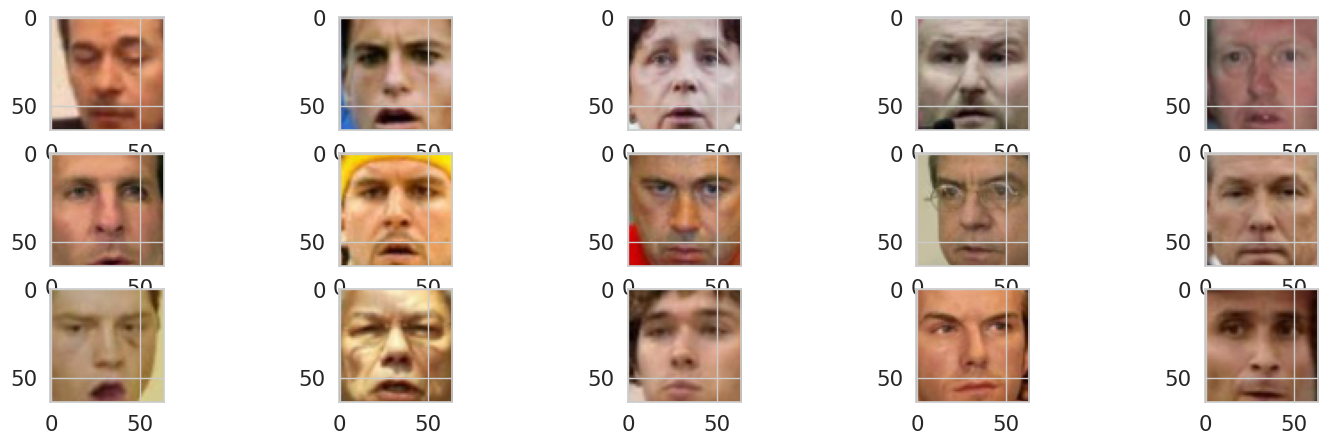

In [53]:
# Найдем фото с грустными эмоциями:

sad_people = list(train_attrs[train_attrs.Smiling<-2.3].index)
print(len(sad_people))

plt.figure(figsize=(18, 5))
a_sad = len(sad_people[:15])
for i in range(a_sad):
    plt.subplot(3, 5, i + 1)
    plt.imshow(train_img[sad_people[i]])

In [54]:
notsmile_latent_space = []
ae_model.eval()
with torch.no_grad():
    for idx in sad_people:
        image = torch.FloatTensor(train_img[idx]).permute(2, 0, 1)
        reconstructed, latent_code = ae_model(image.to(device))
        notsmile_latent_space.append(latent_code)

notsmile_total_space = notsmile_latent_space[0].cpu().numpy()

# Сконкатинируем все латентные состояния улыбающихся людей
for i in range(len(notsmile_latent_space)):
    notsmile_total_space = np.concatenate((notsmile_total_space, notsmile_latent_space[i].cpu().numpy()))

# Найдем среднее и стандартное отклонение
mean_notsmile_sp = np.mean(notsmile_total_space, axis=0)
std_notsmile_sp = np.std(notsmile_total_space, axis=0)

In [55]:
notsmile_randoms = []
for mean, std in zip(mean_notsmile_sp, std_notsmile_sp):
    notsmile_randoms.append(np.random.normal(mean.item(), std.item(), size=notsmile_latent_space[0].size(1)))

#out = ae_model.sample(torch.FloatTensor(notsmile_randoms).to(device))
#plt.figure(figsize=(18, 5))
#for i in range(5):
#    plt.subplot(1, 5, i + 1)
#    plt.imshow(out[i].permute(1, 2, 0).cpu().detach().numpy())

In [56]:
# Получаем вектор улыбки и затем конвертируем латентное пространство грустных людей
smile_vec = mean_smile_sp - mean_notsmile_sp
sad2smile = (notsmile_total_space + smile_vec)

# Собираем тензора грустных людей и их же, но весёлыми
sad_img = ae_model.sample(torch.Tensor(notsmile_total_space).to(device))
sad2smile_img = ae_model.sample(torch.Tensor(sad2smile).to(device))

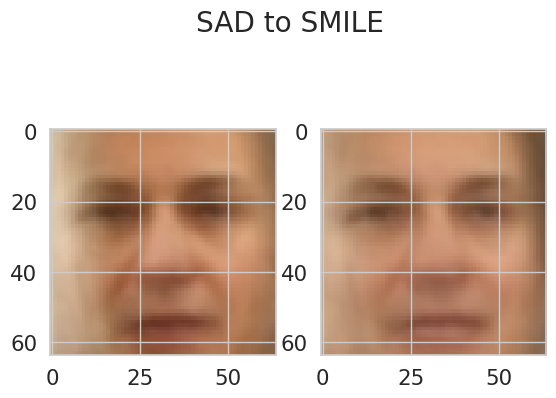

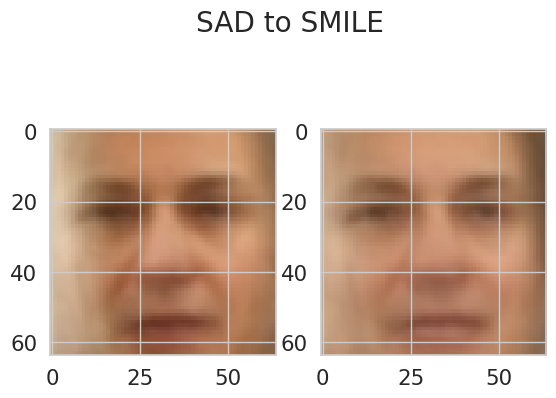

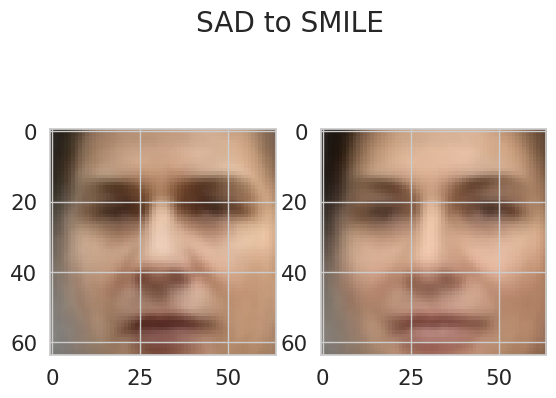

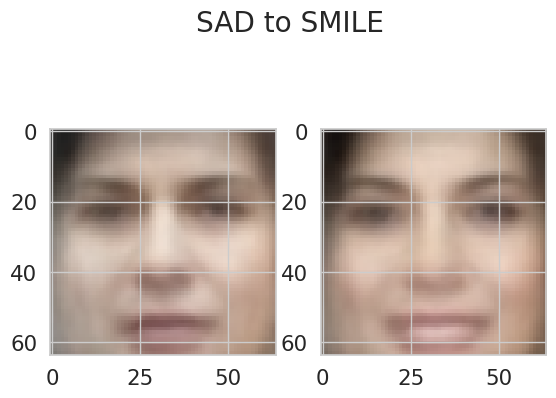

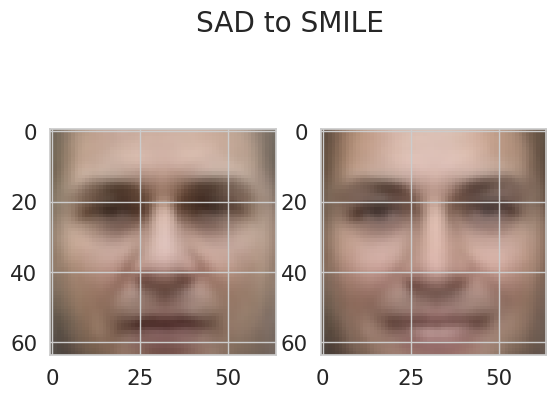

In [57]:
# Отрисуем n фотографий из грустного в веселых
n = 5
for sad, smile in zip(sad_img[:n], sad2smile_img[:n]):
    plt.subplot(1, 2, 1)
    plt.imshow(sad.permute(1, 2, 0).cpu().detach().numpy())
    plt.subplot(1, 2, 2)
    plt.imshow(smile.permute(1, 2, 0).cpu().detach().numpy())
    plt.suptitle(f'SAD to SMILE')
    plt.show()

Вуаля! Вы восхитительны!

Теперь вы можете пририсовывать людям не только улыбки, но и много чего другого -- закрывать/открывать глаза, пририсовывать очки... в общем, все, на что хватит фантазии и на что есть атрибуты в `all_attrs`:)

# Часть 2: Variational Autoencoder (10 баллов)

Займемся обучением вариационных автоэнкодеров — проапгрейженной версии AE. Обучать будем на датасете MNIST, содержащем написанные от руки цифры от 0 до 9

In [64]:
LR = 0.001
DOWNLOAD = True
DATA = './mnist_data/'

In [65]:
transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize((0.5,), (0.5,)),
])

In [66]:
train_dataset = torchvision.datasets.MNIST(
    root=DATA,
    train=True,
    transform=transform,
    download=DOWNLOAD,
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 16.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 480kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.43MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.19MB/s]


In [67]:
batch_size = 32
# MNIST Dataset
train_dataset = datasets.MNIST(root='./mnist_data/', train=True, transform=transforms.ToTensor(), download=False)
test_dataset = datasets.MNIST(root='./mnist_data/', train=False, transform=transforms.ToTensor(), download=False)

# Data Loader (Input Pipeline)
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

## 2.1 Архитектура модели и обучение (2 балла)

Реализуем VAE. Архитектуру (conv, fully-connected, ReLu, etc) можете выбирать сами. Рекомендуем пользоваться более сложными моделями, чем та, что была на семинаре:) Экспериментируйте!

In [68]:
class MyVAE(nn.Module):
    def __init__(self):
        super().__init__()

        self.relu = nn.ReLU()
        self.dwnlinear1 = nn.Linear(in_features=28*28, out_features=256)
        self.dwnlinear2 = nn.Linear(in_features=256, out_features=64)
        self.dwnlinear31 = nn.Linear(in_features=64, out_features=32)
        self.dwnlinear32 = nn.Linear(in_features=64, out_features=32)

        self.uplinear1 = nn.Linear(in_features=32, out_features=64)
        self.uplinear2 = nn.Linear(in_features=64, out_features=256)
        self.uplinear3 = nn.Linear(in_features=256, out_features=28*28)

    def encode(self, x):

        x = x.view(-1, 28*28)
        x = self.relu(self.dwnlinear2(self.relu(self.dwnlinear1(x))))
        mu = self.dwnlinear31(x)
        logsigma = self.dwnlinear32(x)

        return mu, logsigma

    def gaussian_sampler(self, mu, logsigma):
        if self.training:
            std = torch.exp(0.5 * logsigma)
            rand_vec = torch.randn_like(mu)
            sample =  mu + (rand_vec * std)
            return sample
        else:
            # на инференсе возвращаем не случайный вектор из нормального распределения, а центральный -- mu.
            # на инференсе выход автоэнкодера должен быть детерминирован.
            return mu

    def decode(self, z):

        reconstruction = self.relu(self.uplinear2(self.relu(self.uplinear1(z))))
        reconstruction = torch.sigmoid(self.uplinear3(reconstruction))

        return reconstruction

    def forward(self, x):
        mu, logsigma = self.encode(x)
        z = self.gaussian_sampler(mu, logsigma)
        reconstruction = self.decode(z)
        reconstruction = reconstruction.view(-1, 1, 28, 28)

        return mu, logsigma, reconstruction

    def sample(self, z):
        generated = self.decode(z)
        generated = generated.view(-1, 1, 28, 28)
        return generated

Определим лосс и его компоненты для VAE:

Надеюсь, вы уже прочитали материал в towardsdatascience (или еще где-то) про VAE и знаете, что лосс у VAE состоит из двух частей: KL и log-likelihood.

Общий лосс будет выглядеть так:

$$\mathcal{L} = -D_{KL}(q_{\phi}(z|x)||p(z)) + \log p_{\theta}(x|z)$$

Формула для KL-дивергенции:

$$D_{KL} = -\frac{1}{2}\sum_{i=1}^{dimZ}(1+log(\sigma_i^2)-\mu_i^2-\sigma_i^2)$$

В качестве log-likelihood возьмем привычную нам кросс-энтропию.

In [69]:
def KL_divergence(mu, logsigma):
    """
    часть функции потерь, которая отвечает за "близость" латентных представлений разных людей
    """
    loss = -0.5 * torch.sum(1 + logsigma - mu.pow(2) - logsigma.exp())
    return loss

def log_likelihood(x, reconstruction):
    """
    часть функции потерь, которая отвечает за качество реконструкции
    """
    loss = nn.BCELoss(reduction='sum')
    return loss(reconstruction, x)

def loss_vae(x, mu, logsigma, reconstruction):
    return KL_divergence(mu, logsigma) + log_likelihood(x, reconstruction)

И обучим модель:

  0%|          | 0/30 [00:00<?, ?it/s]

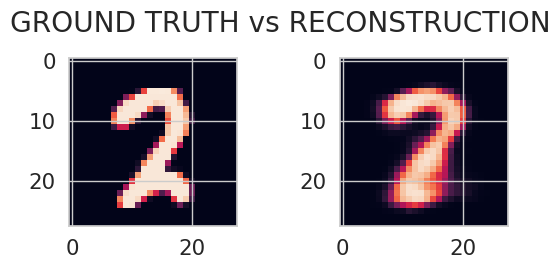

EPOCH 1: 
**TRAIN** loss: 4657.556771484375 **EVAL** loss: 4111.880586374301 
 ------------------------------------------------------------------------------------------------------------------------------------------------------


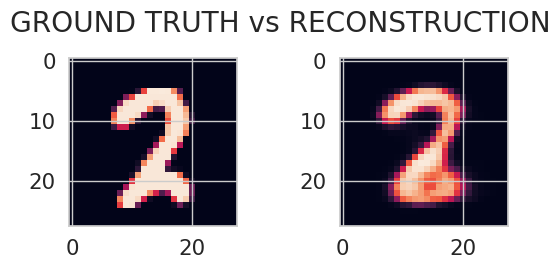

EPOCH 3: 
**TRAIN** loss: 3956.6264139322916 **EVAL** loss: 3624.4388462834463 
 ------------------------------------------------------------------------------------------------------------------------------------------------------


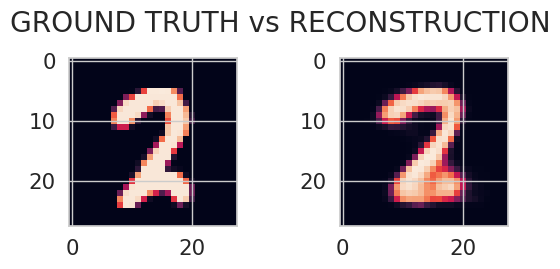

EPOCH 5: 
**TRAIN** loss: 3711.369601953125 **EVAL** loss: 3452.139633617462 
 ------------------------------------------------------------------------------------------------------------------------------------------------------


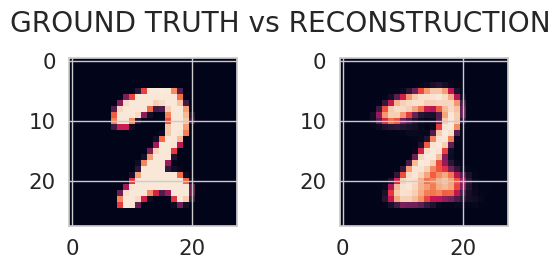

EPOCH 7: 
**TRAIN** loss: 3598.933887760417 **EVAL** loss: 3358.433555529902 
 ------------------------------------------------------------------------------------------------------------------------------------------------------


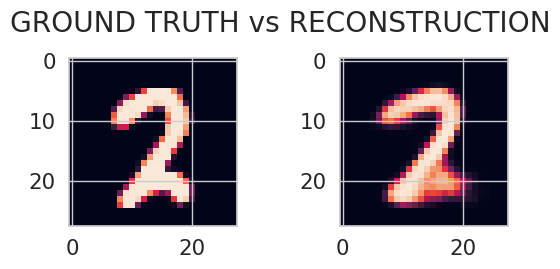

EPOCH 9: 
**TRAIN** loss: 3531.119948958333 **EVAL** loss: 3294.6362776588708 
 ------------------------------------------------------------------------------------------------------------------------------------------------------


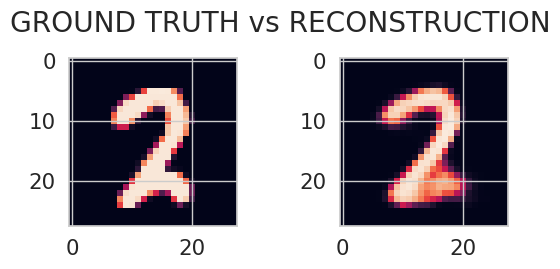

EPOCH 11: 
**TRAIN** loss: 3480.7026513020833 **EVAL** loss: 3249.0753193328173 
 ------------------------------------------------------------------------------------------------------------------------------------------------------


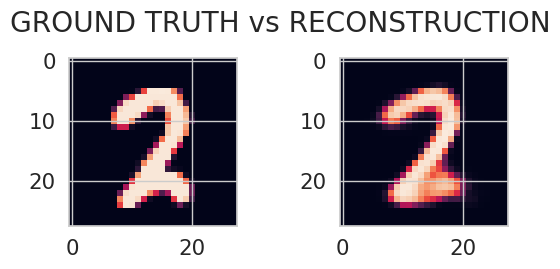

EPOCH 13: 
**TRAIN** loss: 3446.261054166667 **EVAL** loss: 3229.642060593675 
 ------------------------------------------------------------------------------------------------------------------------------------------------------


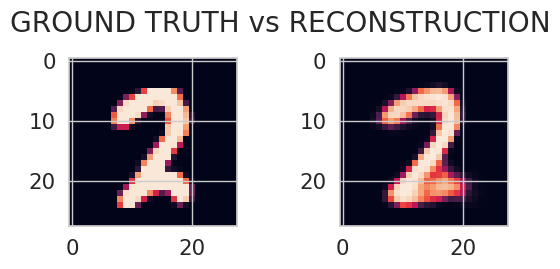

EPOCH 15: 
**TRAIN** loss: 3419.96938515625 **EVAL** loss: 3199.5157104102186 
 ------------------------------------------------------------------------------------------------------------------------------------------------------


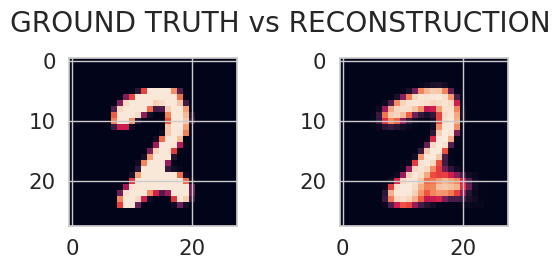

EPOCH 17: 
**TRAIN** loss: 3399.143796484375 **EVAL** loss: 3194.5792099827777 
 ------------------------------------------------------------------------------------------------------------------------------------------------------


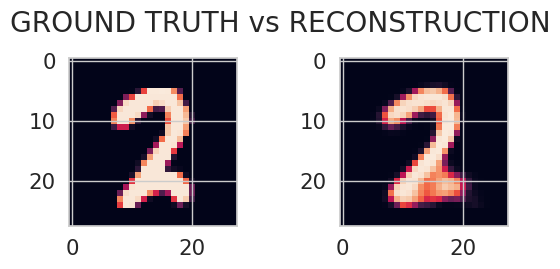

EPOCH 19: 
**TRAIN** loss: 3381.2464401041666 **EVAL** loss: 3168.785661691294 
 ------------------------------------------------------------------------------------------------------------------------------------------------------


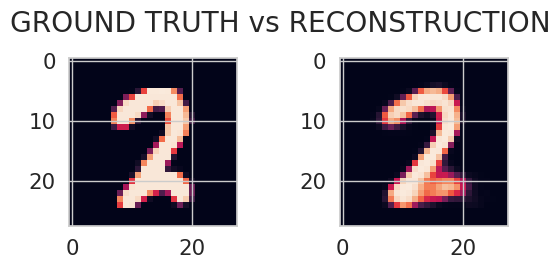

EPOCH 21: 
**TRAIN** loss: 3365.97385859375 **EVAL** loss: 3153.113801511332 
 ------------------------------------------------------------------------------------------------------------------------------------------------------


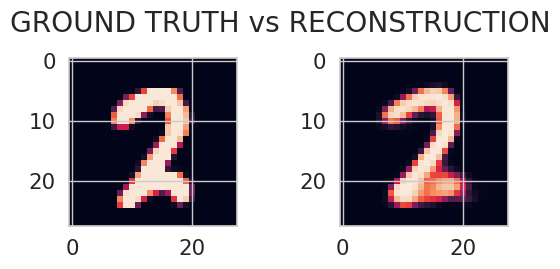

EPOCH 23: 
**TRAIN** loss: 3352.975613671875 **EVAL** loss: 3138.2463839107427 
 ------------------------------------------------------------------------------------------------------------------------------------------------------


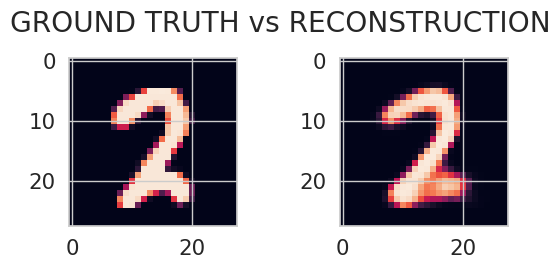

EPOCH 25: 
**TRAIN** loss: 3342.2298977864584 **EVAL** loss: 3123.6993326302913 
 ------------------------------------------------------------------------------------------------------------------------------------------------------


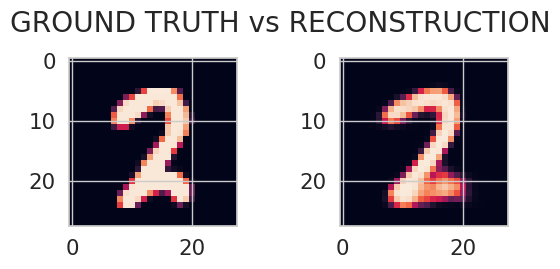

EPOCH 27: 
**TRAIN** loss: 3331.98976640625 **EVAL** loss: 3139.7945720441044 
 ------------------------------------------------------------------------------------------------------------------------------------------------------


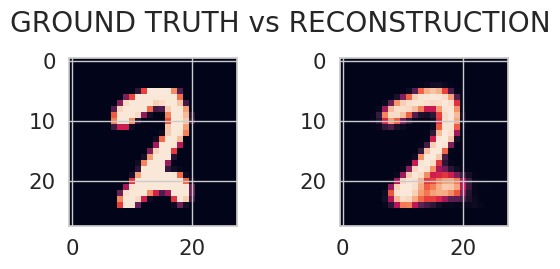

EPOCH 29: 
**TRAIN** loss: 3323.5580104166665 **EVAL** loss: 3123.6404050394367 
 ------------------------------------------------------------------------------------------------------------------------------------------------------


In [70]:
EPOCHS = 30

criterion = loss_vae
vae_model = MyVAE().to(device)
optimizer = torch.optim.Adam(vae_model.parameters(), lr=3e-4)

vae_history_losses = {'train':[],'valid':[]}

for epoch in tqdm(range(EPOCHS)):
    vae_model.train()
    train_loss = 0
    for batch, _ in train_loader:
        optimizer.zero_grad()
        batch = batch.float().to(device)
        mu, logsigma, reconstruction = vae_model(batch)
        loss = criterion(batch, mu, logsigma, reconstruction)
        loss.backward()
        optimizer.step()
        train_loss+=loss.item()
    vae_history_losses['train'].append(train_loss/len(train_loader))

    vae_model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch, _ in test_loader:
            batch = batch.float().to(device)
            mu, logsigma, reconstruction = vae_model(batch)
            loss = criterion(batch, mu, logsigma, reconstruction)
            val_loss+=loss.item()
        vae_history_losses['valid'].append(val_loss/len(test_loader))

    if epoch%2:
        gt = batch.cpu()[1].permute(1, 2, 0).detach().numpy()
        res = reconstruction.cpu()[1].permute(1, 2, 0).detach().numpy()
        plt.subplot(2, 2, 1)
        plt.imshow(gt)
        plt.subplot(2, 2, 2)
        plt.imshow(res)
        plt.suptitle(f'GROUND TRUTH vs RECONSTRUCTION')
        plt.show()

        print('EPOCH {}:'.format(epoch), "\n**TRAIN** loss:", train_loss/len(train_loader), "**EVAL** loss:",val_loss/len(test_loader),'\n','-'*150)

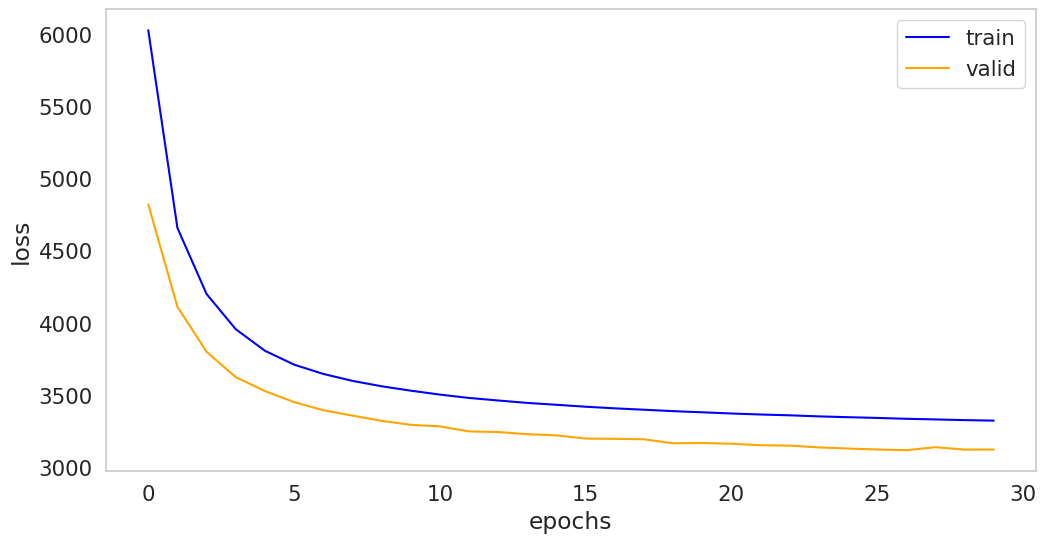

In [71]:
history_plot(vae_history_losses)

In [72]:
if SAVE:
    torch.save(vae_model.state_dict(), 'vae_model.pt')

Давайте посмотрим, как наш тренированный VAE кодирует и восстанавливает картинки:

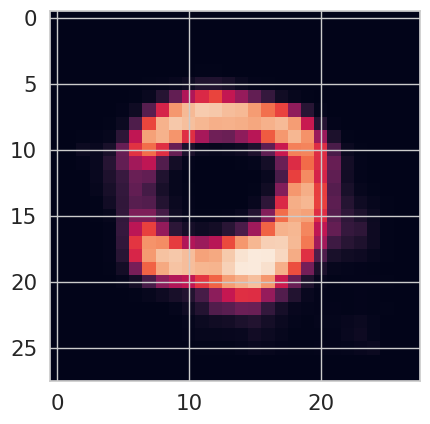

In [73]:
rand_img = np.random.normal(0, 1, size=(1, 32))
output = vae_model.sample(torch.FloatTensor(rand_img).float().to(device))
output = output.view(28, 28, 1).cpu().detach().numpy()
plt.imshow(output)
None

In [74]:
def compare_mnist(model, loader, n_out):

    x, _ = next(iter(loader))
    model.eval()
    with torch.no_grad():
        _, _, res = model(x.float().to(device))

    for i in range(n_out):
        plt.subplot(n_out*1, 2, 1)
        plt.imshow(x.cpu()[i].permute(1, 2, 0).detach().numpy())
        plt.subplot(n_out*1, 2, 2)
        plt.imshow(res.cpu()[i].permute(1, 2, 0).detach().numpy())
        plt.suptitle(f'GROUND TRUTH vs RECONSTRUCTION')
        plt.show()

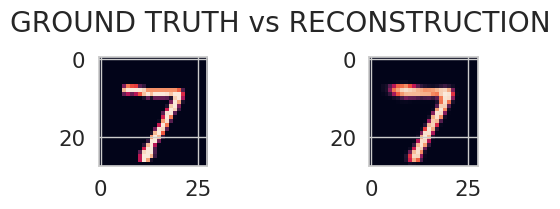

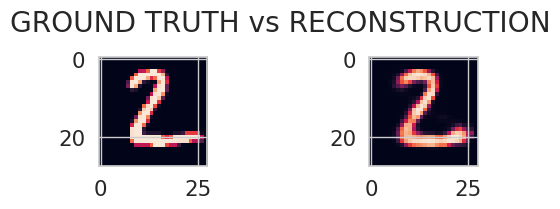

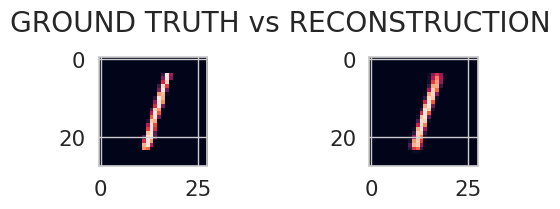

In [75]:
compare_mnist(vae_model, test_loader, 3)

Давайте попробуем проделать для VAE то же, что и с обычным автоэнкодером -- подсунуть decoder'у из VAE случайные векторы из нормального распределения и посмотреть, какие картинки получаются:

In [76]:
latent_space = []
vae_model.eval()
with torch.no_grad():
    for batch,_ in train_loader:
        batch = batch.float().to(device)
        mu, logsigma, reconstruction = vae_model(batch)
        latent_space.append(mu)
total_space = latent_space[0].cpu().numpy()

# Сконкатинируем все латентные состояния
for i in range(len(latent_space)):
    total_space = np.concatenate((total_space, latent_space[i].cpu().numpy()))

# Найдем среднее и стандартное отклонение
mean_sp = np.mean(total_space, axis=0)
std_sp = np.std(total_space, axis=0)

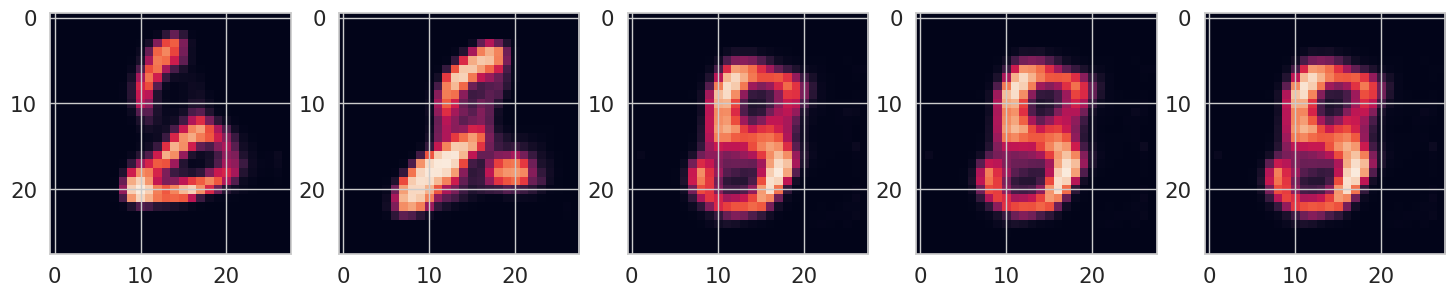

In [77]:
randoms = []
for mean, std in zip(mean_sp, std_sp):
    randoms.append(np.random.normal(mean.item(), std.item(), size=latent_space[0].size(1)))

out = vae_model.sample(torch.FloatTensor(randoms).to(device))
plt.figure(figsize=(18, 5))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(out[i].permute(1, 2, 0).cpu().detach().numpy())

## 2.2. Latent Representation (2 балла)

Давайте посмотрим, как латентные векторы картинок лиц выглядят в пространстве.
Ваша задача -- изобразить латентные векторы картинок точками в двумерном просторанстве.

Это позволит оценить, насколько плотно распределены латентные векторы изображений цифр в пространстве.

Плюс давайте сделаем такую вещь: покрасим точки, которые соответствуют картинкам каждой цифры, в свой отдельный цвет

Подсказка: красить -- это просто =) У plt.scatter есть параметр c (color), см. в документации.


Итак, план:
1. Получить латентные представления картинок тестового датасета
2. С помощтю `TSNE` (есть в `sklearn`) сжать эти представления до размерности 2 (чтобы можно было их визуализировать точками в пространстве)
3. Визуализировать полученные двумерные представления с помощью `matplotlib.scatter`, покрасить разными цветами точки, соответствующие картинкам разных цифр.

In [78]:
from sklearn.manifold import TSNE

vae_model.eval()
latent_d = []
label = []
with torch.no_grad():
    for X_batch, y_batch in iter(test_dataset):
        X_batch = X_batch.to(device)
        mu, logsigma, reconstruction = vae_model(X_batch)
        latent_d.append(mu.cpu().view(32).numpy())
        label.append(y_batch)
latent_d = np.asarray(latent_d)

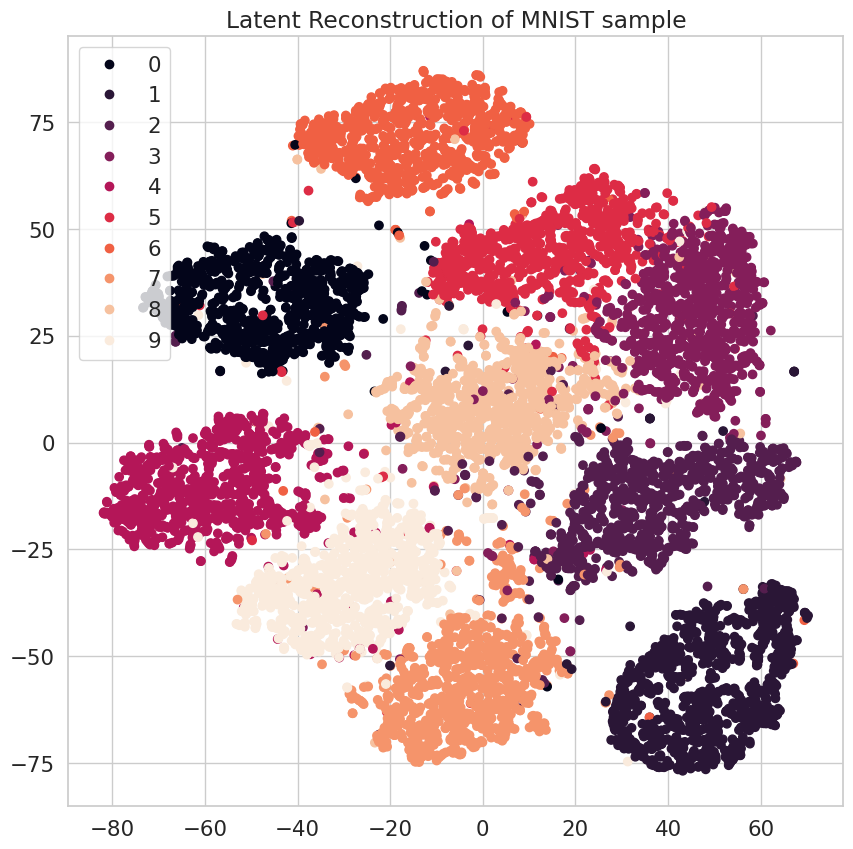

In [79]:
tsne_model = TSNE()
tsne_res = tsne_model.fit_transform(latent_d)

fig = plt.figure( figsize=(10,10) )
ax = fig.add_subplot(1, 1, 1, title='Latent Reconstruction of MNIST sample' )
scatter = ax.scatter(
    x=tsne_res[:,0],
    y=tsne_res[:,1],
    c=label)
ax.legend(*scatter.legend_elements())
plt.show()

Что вы думаете о виде латентного представления?

Классы таргета распределились во своим кластерам. Есть точечные пересечения, объяснимые схожестью написания цифр

__Congrats v2.0!__

## 2.3. Conditional VAE (6 баллов)


Мы уже научились обучать обычный AE на датасете картинок и получать новые картинки, используя генерацию шума и декодер.
Давайте теперь допустим, что мы обучили AE на датасете MNIST и теперь хотим генерировать новые картинки с числами с помощью декодера (как выше мы генерили рандомные лица).
И вот нам понадобилось сгенерировать цифру 8, и мы подставляем разные варианты шума, но восьмерка никак не генерится:(

Хотелось бы добавить к нашему AE функцию "выдай мне рандомное число из вот этого вот класса", где классов десять (цифры от 0 до 9 образуют десять классов).  Conditional AE — так называется вид автоэнкодера, который предоставляет такую возможность. Ну, название "conditional" уже говорит само за себя.

И в этой части задания мы научимся такие обучать.

### Архитектура

На картинке ниже представлена архитектура простого Conditional VAE.

По сути, единственное отличие от обычного -- это то, что мы вместе с картинкой в первом слое энкодера и декодера передаем еще информацию о классе картинки.

То есть, в первый (входной) слой энкодера подается конкатенация картинки и информации о классе (например, вектора из девяти нулей и одной единицы). В первый слой декодера подается конкатенация латентного вектора и информации о классе.


![alt text](https://sun9-63.userapi.com/impg/Mh1akf7mfpNoprrSWsPOouazSmTPMazYYF49Tw/djoHNw_9KVA.jpg?size=1175x642&quality=96&sign=e88baec5f9bb91c8443fba31dcf0a4df&type=album)

![alt text](https://sun9-73.userapi.com/impg/UDuloLNKhzTBYAKewgxke5-YPsAKyGOqA-qCRg/MnyCavJidxM.jpg?size=1229x651&quality=96&sign=f2d21bfacc1c5755b76868dc4cfef39c&type=album)



На всякий случай: это VAE, то есть, latent у него все еще состоит из mu и sigma

Таким образом, при генерации новой рандомной картинки мы должны будем передать декодеру сконкатенированные латентный вектор и класс картинки.

P.S. Также можно передавать класс картинки не только в первый слой, но и в каждый слой сети. То есть на каждом слое конкатенировать выход из предыдущего слоя и информацию о классе.

In [80]:
class MyCVAE(nn.Module):
    def __init__(self, hidden_size:int=32):
        super().__init__()
        size_label = 28*28 + 10
        hidden_size += 10
        hidden_size_label = hidden_size + 10

        self.relu = nn.ReLU()
        self.dwnlinear1 = nn.Linear(in_features=size_label, out_features=256)
        self.dwnlinear2 = nn.Linear(in_features=256, out_features=64)
        self.dwnlinear31 = nn.Linear(in_features=64, out_features=hidden_size)
        self.dwnlinear32 = nn.Linear(in_features=64, out_features=hidden_size)

        self.uplinear1 = nn.Linear(in_features=hidden_size_label, out_features=64)
        self.uplinear2 = nn.Linear(in_features=64, out_features=256)
        self.uplinear3 = nn.Linear(in_features=256, out_features=28*28)

    def encode(self, x, y):

        x = x.view(-1, 28*28)
        x = torch.cat((x, y), 1)
        x = self.relu(self.dwnlinear2(self.relu(self.dwnlinear1(x))))
        mu = self.dwnlinear31(x)
        logsigma = self.dwnlinear32(x)

        return mu, logsigma

    def gaussian_sampler(self, mu, logsigma):
        if self.training:
            std = torch.exp(0.5 * logsigma)
            rand_vec = torch.randn_like(mu)
            sample =  mu + (rand_vec * std)
            return sample
        else:
            # на инференсе возвращаем не случайный вектор из нормального распределения, а центральный -- mu.
            # на инференсе выход автоэнкодера должен быть детерминирован.
            return mu

    def decode(self, z, y):

        z = torch.cat((z, y), 1)
        reconstruction = self.relu(self.uplinear2(self.relu(self.uplinear1(z))))
        reconstruction = torch.sigmoid(self.uplinear3(reconstruction))

        return reconstruction

    def forward(self, x, y):
        mu, logsigma = self.encode(x, y)
        z = self.gaussian_sampler(mu, logsigma)
        reconstruction = self.decode(z, y)
        reconstruction = reconstruction.view(-1, 1, 28, 28)

        return mu, logsigma, reconstruction

    def sample(self, z, y):
        generated = self.decode(z, y)
        generated = generated.view(-1, 1, 28, 28)
        return generated

  0%|          | 0/30 [00:00<?, ?it/s]

<ipython-input-81-d9aa6cef1229>:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_batch = F.one_hot(torch.tensor(y_batch), 10).to(device)
<ipython-input-81-d9aa6cef1229>:26: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_batch = F.one_hot(torch.tensor(y_batch), 10).to(device)


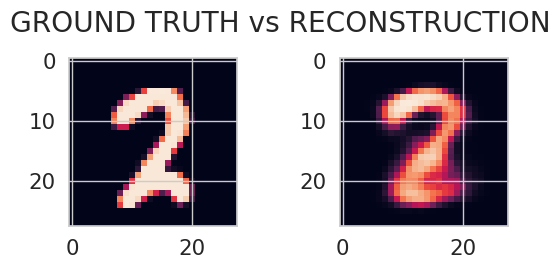

EPOCH 1: 
**TRAIN** loss: 4555.216622265625 **EVAL** loss: 3983.146989816294 
 ------------------------------------------------------------------------------------------------------------------------------------------------------


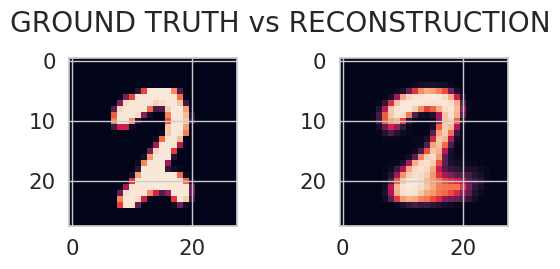

EPOCH 3: 
**TRAIN** loss: 3861.7667897135416 **EVAL** loss: 3506.06176952813 
 ------------------------------------------------------------------------------------------------------------------------------------------------------


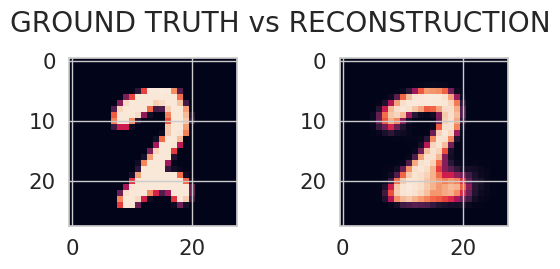

EPOCH 5: 
**TRAIN** loss: 3599.8300869791665 **EVAL** loss: 3311.8696792163787 
 ------------------------------------------------------------------------------------------------------------------------------------------------------


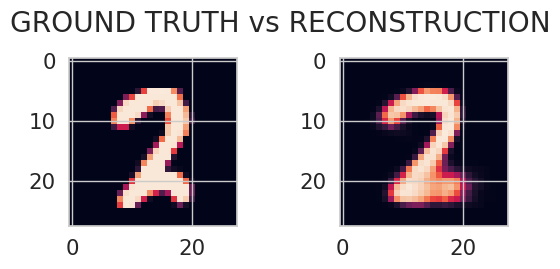

EPOCH 7: 
**TRAIN** loss: 3484.3888319010416 **EVAL** loss: 3226.313450822434 
 ------------------------------------------------------------------------------------------------------------------------------------------------------


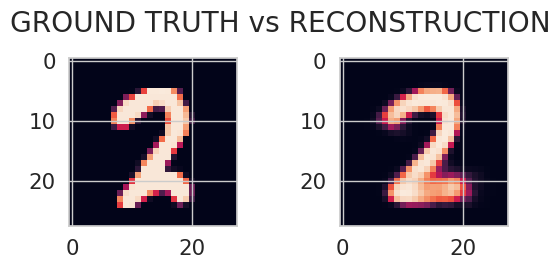

EPOCH 9: 
**TRAIN** loss: 3410.9726731770834 **EVAL** loss: 3154.145043321311 
 ------------------------------------------------------------------------------------------------------------------------------------------------------


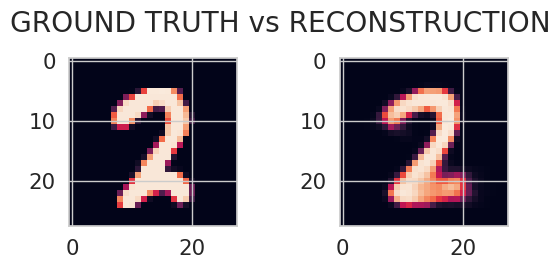

EPOCH 11: 
**TRAIN** loss: 3359.54506015625 **EVAL** loss: 3127.5921158958167 
 ------------------------------------------------------------------------------------------------------------------------------------------------------


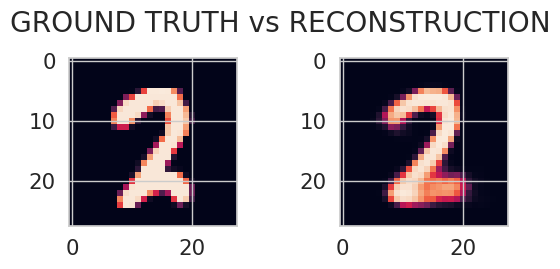

EPOCH 13: 
**TRAIN** loss: 3318.536181901042 **EVAL** loss: 3075.9673865565096 
 ------------------------------------------------------------------------------------------------------------------------------------------------------


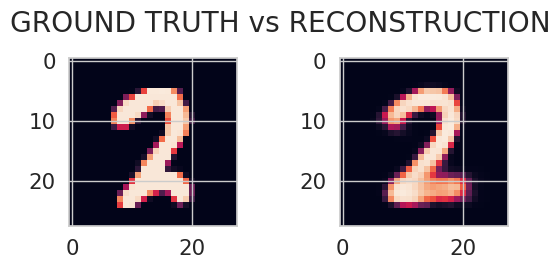

EPOCH 15: 
**TRAIN** loss: 3288.795594140625 **EVAL** loss: 3064.6505801654853 
 ------------------------------------------------------------------------------------------------------------------------------------------------------


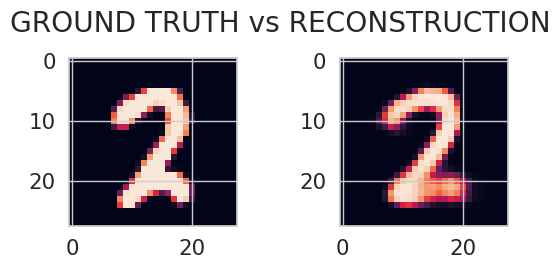

EPOCH 17: 
**TRAIN** loss: 3264.4390359375 **EVAL** loss: 3036.4976713040387 
 ------------------------------------------------------------------------------------------------------------------------------------------------------


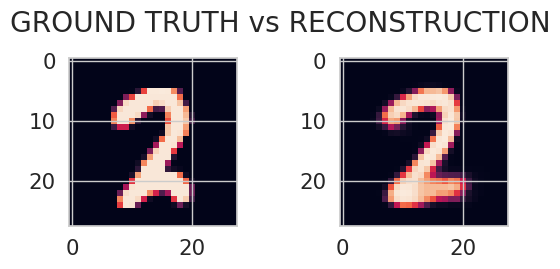

EPOCH 19: 
**TRAIN** loss: 3242.3956475260416 **EVAL** loss: 3021.3315671488117 
 ------------------------------------------------------------------------------------------------------------------------------------------------------


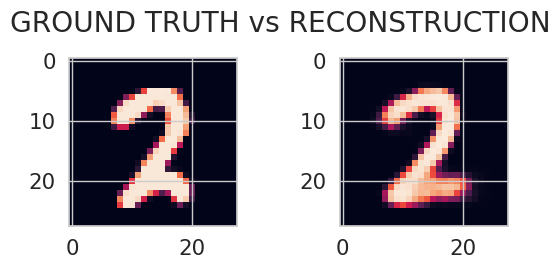

EPOCH 21: 
**TRAIN** loss: 3227.22085 **EVAL** loss: 3000.7553835737817 
 ------------------------------------------------------------------------------------------------------------------------------------------------------


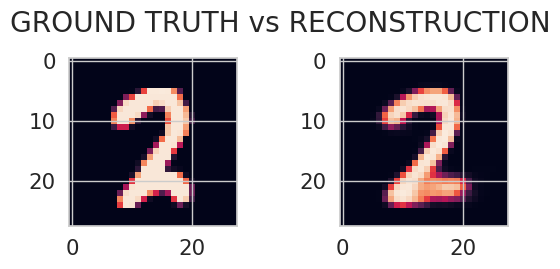

EPOCH 23: 
**TRAIN** loss: 3211.0260856770833 **EVAL** loss: 2979.8646985136284 
 ------------------------------------------------------------------------------------------------------------------------------------------------------


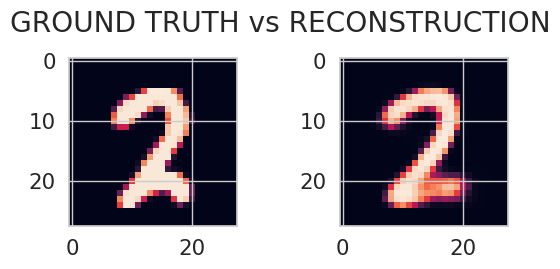

EPOCH 25: 
**TRAIN** loss: 3197.397866927083 **EVAL** loss: 2976.125251940645 
 ------------------------------------------------------------------------------------------------------------------------------------------------------


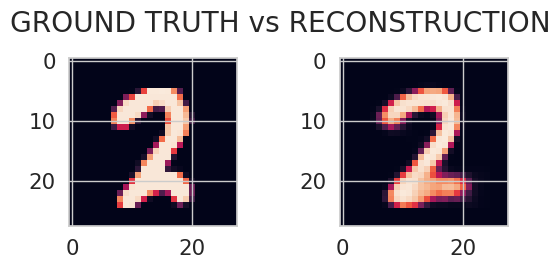

EPOCH 27: 
**TRAIN** loss: 3186.352930078125 **EVAL** loss: 2968.078320780501 
 ------------------------------------------------------------------------------------------------------------------------------------------------------


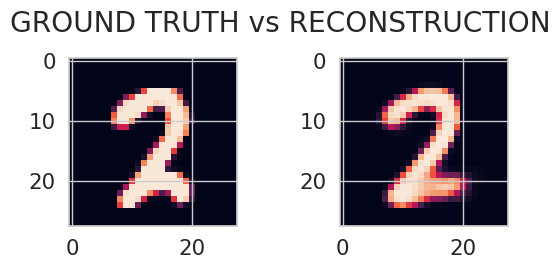

EPOCH 29: 
**TRAIN** loss: 3176.5155040364584 **EVAL** loss: 2952.1749255878094 
 ------------------------------------------------------------------------------------------------------------------------------------------------------


In [81]:
criterion = loss_vae
cvae_model = MyCVAE().to(device)
optimizer = torch.optim.Adam(cvae_model.parameters(), lr=3e-4)

cvae_history_losses = {'train':[],'valid':[]}

for epoch in tqdm(range(EPOCHS)):
    cvae_model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        X_batch = X_batch.float().to(device)
        y_batch = F.one_hot(torch.tensor(y_batch), 10).to(device)
        mu, logsigma, reconstruction = cvae_model(X_batch,y_batch)
        loss = criterion(X_batch, mu, logsigma, reconstruction)
        loss.backward()
        optimizer.step()
        train_loss+=loss.item()
    cvae_history_losses['train'].append(train_loss/len(train_loader))

    cvae_model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.float().to(device)
            y_batch = F.one_hot(torch.tensor(y_batch), 10).to(device)
            mu, logsigma, reconstruction = cvae_model(X_batch, y_batch)
            loss = criterion(X_batch, mu, logsigma, reconstruction)
            val_loss+=loss.item()
        cvae_history_losses['valid'].append(val_loss/len(test_loader))

    if epoch%2:
        gt = X_batch.cpu()[1].permute(1, 2, 0).detach().numpy()
        res = reconstruction.cpu()[1].permute(1, 2, 0).detach().numpy()
        plt.subplot(2, 2, 1)
        plt.imshow(gt)
        plt.subplot(2, 2, 2)
        plt.imshow(res)
        plt.suptitle(f'GROUND TRUTH vs RECONSTRUCTION')
        plt.show()

        print('EPOCH {}:'.format(epoch), "\n**TRAIN** loss:", train_loss/len(train_loader), "**EVAL** loss:",val_loss/len(test_loader),'\n','-'*150)

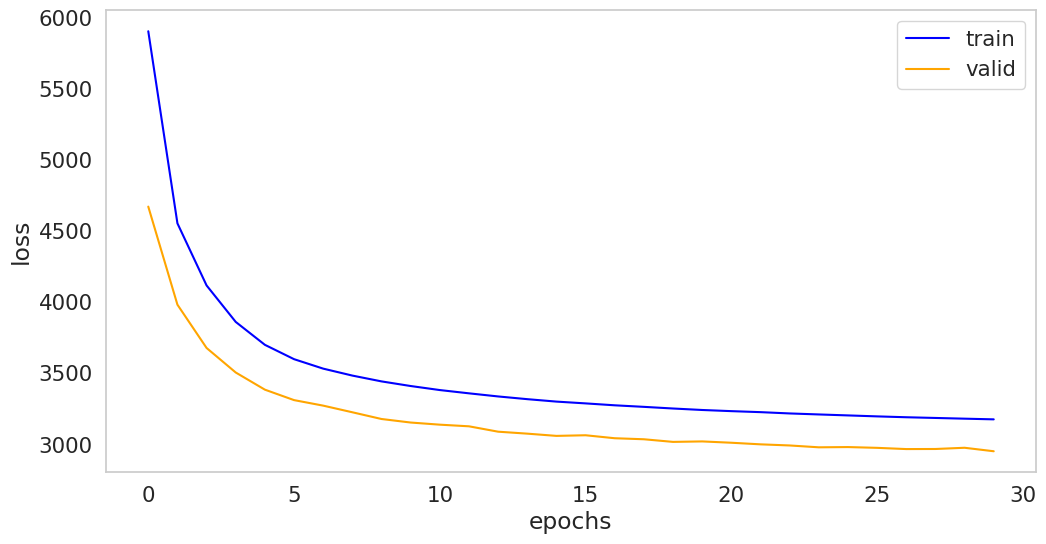

In [82]:
history_plot(cvae_history_losses)

In [83]:
if SAVE:
    torch.save(cvae_model.state_dict(), 'cvae_model.pt')

### Sampling


Тут мы будем сэмплировать из CVAE. Это прикольнее, чем сэмплировать из простого AE/VAE: тут можно взять один и тот же латентный вектор и попросить CVAE восстановить из него картинки разных классов!
Для MNIST вы можете попросить CVAE восстановить из одного латентного вектора, например, картинки цифры 5 и 7.

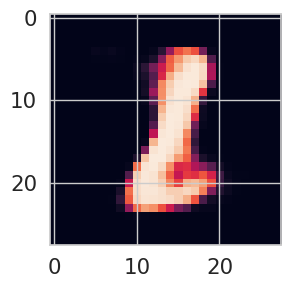

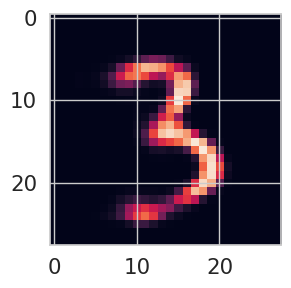

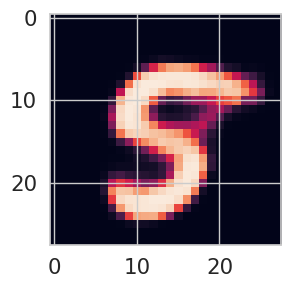

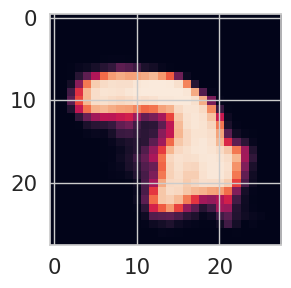

In [84]:
cvae_model.eval()
for i in [1,3,5,7]:
    plt.figure(figsize=(6, 3))
    x = torch.FloatTensor(np.random.normal(0, 1, size=(1, 32+10))).to(device)
    y = F.one_hot(torch.tensor(i), 10).view(1, -1).to(device)
    plt.imshow(cvae_model.sample(x, y).cpu().view(28,28,1).detach().numpy())
    plt.show()

Splendid! Вы великолепны!


### Latent Representations

Давайте посмотрим, как выглядит латентное пространство картинок в CVAE и сравним с картинкой для VAE =)

Опять же, нужно покрасить точки в разные цвета в зависимости от класса.

In [85]:
cvae_model.eval()
latent_d = []
label = []
with torch.no_grad():
    for X_batch, y_batch in iter(test_dataset):
        label.append(y_batch)
        X_batch = X_batch.to(device)
        y_batch = F.one_hot(torch.tensor(y_batch), 10).view(1, -1).to(device)
        mu, logsigma, reconstruction = cvae_model(X_batch, y_batch)
        latent_d.append(mu.cpu().view(32+10).numpy())

latent_d = np.asarray(latent_d)

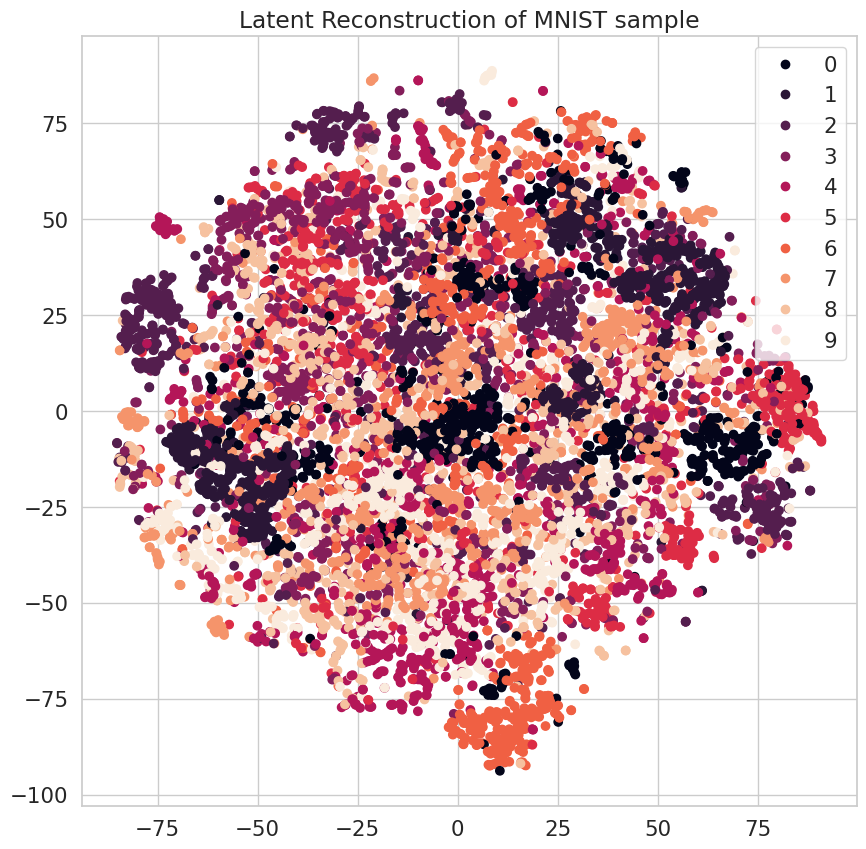

In [86]:
tsne_model = TSNE()
tsne_res = tsne_model.fit_transform(latent_d)

fig = plt.figure( figsize=(10,10) )
ax = fig.add_subplot(1, 1, 1, title='Latent Reconstruction of MNIST sample' )
scatter = ax.scatter(
    x=tsne_res[:,0],
    y=tsne_res[:,1],
    c=label)
ax.legend(*scatter.legend_elements())
plt.show()

Что вы думаете насчет этой картинки? Отличается от картинки для VAE?

Latent Representation в архитектуре CVAE, относительно архитектуры VAE имеет вид пузыря! Это и есть основное отличие, где все классы таргета перемешанны, а некоторые кластеры цифр образуются в разных частях, что наталкивает на мысль о том, что цифры из этих кластеров похожи друг на друга, к примеру: 1 ~ 7, 3 ~ 9 и др.х.

In [87]:
# Отрисовка графиков обучения

def history_plot_models(history_loss1,history_loss2, names:list=['train','valid']):

    fig, ax = plt.subplots(1,2, figsize=(16, 6))
    ax[0].plot(history_loss1[names[0]], label=f"VAE_{names[0]}_loss",color='blue')
    ax[0].plot(history_loss2[names[0]], label=f"CVAE_{names[0]}_loss",color='orange')
    ax[0].legend()
    ax[0].set_xlabel('epochs')
    ax[0].set_ylabel("loss")
    plt.grid()

    ax[1].plot(history_loss1[names[1]], label=f"VAE_{names[1]}_loss",color='blue')
    ax[1].plot(history_loss2[names[1]], label=f"CVAE_{names[1]}_loss",color='orange')
    ax[1].legend()
    ax[1].set_xlabel('epochs')
    ax[1].set_ylabel("loss")
    plt.grid()

    fig.suptitle(f"Comparing loss of the models")

    plt.show()

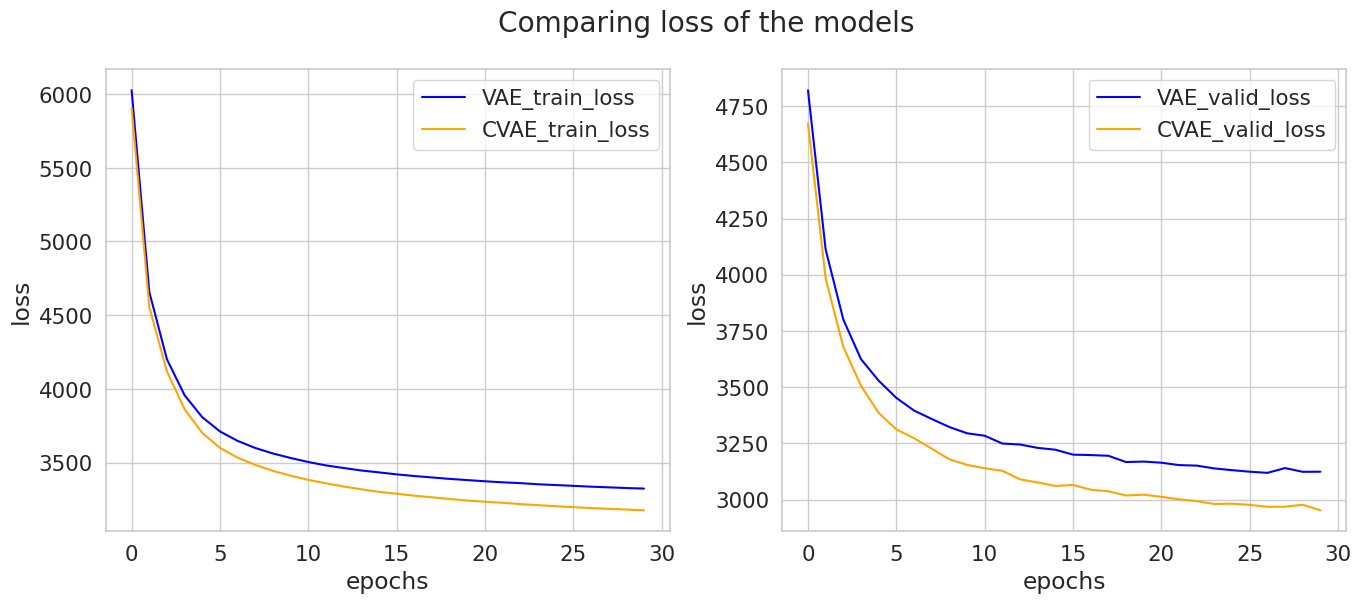

In [88]:
history_plot_models(vae_history_losses,cvae_history_losses)

---
## Выводы по работе:
1) Получилось обучить АЕ для генерации лиц. В архитектуре использовались линейные слои, с батчнормом, дропаутом (который изменяется относительно количества выходных/входных нейронов) и функцией активации ReLU. Усложнял архитектуру только потому, что при более легкой реализации сталкивался со взрывом переобучения при большом значении эпох. Динамический дропаут и батчнорм спасли ситуацию с переобученим. Модель сходится, обучается и показывает довольно таки хорошие результаты. Также по эксперименту заменты латентного состояния грузных лиц на улыбающиеся показал себя хорошим образом, на всех 5 картинках лиц заметно изменение лица.
2) Получилось обучить VAE для генерации цифр. В архитектуре также присутствовали линейные слои с функцией активации ReLU. Усложнять не пришлось, так как датасет достаточно простой и с переобучением не столкнулся! Модель показывает себя хорошо, при кластеризации TNSE видим, что каждый из классов попадает в свой кластер!
3) Получилось обучить СVAE для генерации цифр. В архитектуре также присутствовали линейные слои с функцией активации ReLU и конкатинацией таргета с векторным представлением характеристик изображения. Архитектура CVAE показывает себя лучше, чем архитектура VAE по loss функции. Однако Latent Representation в архитектуре CVAE, относительно архитектуры VAE имеет вид пузыря.

# BONUS 1: Denoising

## Внимание! За бонусы доп. баллы не ставятся, но вы можете сделать их для себя.

У автоэнкодеров, кроме сжатия и генерации изображений, есть другие практические применения. Про одно из них эта бонусная часть задания.

Автоэнкодеры могут быть использованы для избавления от шума на фотографиях (denoising). Для этого их нужно обучить специальным образом: input картинка будет зашумленной, а выдавать автоэнкодер должен будет картинку без шума.
То есть, loss-функция AE останется той же (MSE между реальной картинкой и выданной), а на вход автоэнкодеру будет подаваться зашумленная картинка.

<a href="https://ibb.co/YbRJ1nZ"><img src="https://i.ibb.co/0QD164t/Screen-Shot-2020-06-04-at-4-49-50-PM.png" alt="Screen-Shot-2020-06-04-at-4-49-50-PM" border="0"></a>

Для этого нужно взять ваш любимый датасет (датасет лиц из первой части этого задания или любой другой) и сделать копию этого датасета с шумом.

В питоне шум можно добавить так:

In [ ]:
noise_factor = 0.5
X_noisy = X + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=X.shape)

In [ ]:
<тут ваш код обучения автоэнкодера на зашумленных картинках. Не забудтье разбить на train/test!>

In [ ]:
<тут проверка, как AE убирает щум с тестовых картинок. Надеюсь, все получилось =)>

# BONUS 2: Image Retrieval

## Внимание! За бонусы доп. баллы не ставятся, но вы можете сделать их для себя.

Давайте представим, что весь наш тренировочный датасет -- это большая база данных людей. И вот мы получили картинку лица какого-то человека с уличной камеры наблюдения (у нас это картинка из тестового датасета) и хотим понять, что это за человек. Что нам делать? Правильно -- берем наш VAE, кодируем картинку в латентное представление и ищем среди латентныз представлений лиц нашей базы самые ближайшие!

План:

1. Получаем латентные представления всех лиц тренировочного датасета
2. Обучаем на них LSHForest `(sklearn.neighbors.LSHForest)`, например, с `n_estimators=50`
3. Берем картинку из тестового датасета, с помощью VAE получаем ее латентный вектор
4. Ищем с помощью обученного LSHForest ближайшие из латентных представлений тренировочной базы
5. Находим лица тренировочного датасета, которым соответствуют ближайшие латентные представления, визуализируем!

Немного кода вам в помощь: (feel free to delete everything and write your own)

In [ ]:
codes = <поучите латентные представления картинок из трейна>

In [ ]:
# обучаем LSHForest
from sklearn.neighbors import LSHForest
lshf = LSHForest(n_estimators=50).fit(codes)

In [ ]:
def get_similar(image, n_neighbors=5):
  # функция, которая берет тестовый image и с помощью метода kneighbours у LSHForest ищет ближайшие векторы
  # прогоняет векторы через декодер и получает картинки ближайших людей

  code = <получение латентного представления image>

  (distances,),(idx,) = lshf.kneighbors(code, n_neighbors=n_neighbors)

  return distances, X_train[idx]

In [ ]:
def show_similar(image):

  # функция, которая принимает тестовый image, ищет ближайшие к нему и визуализирует результат

    distances,neighbors = get_similar(image,n_neighbors=11)

    plt.figure(figsize=[8,6])
    plt.subplot(3,4,1)
    plt.imshow(image.cpu().numpy().transpose([1,2,0]))
    plt.title("Original image")

    for i in range(11):
        plt.subplot(3,4,i+2)
        plt.imshow(neighbors[i].cpu().numpy().transpose([1,2,0]))
        plt.title("Dist=%.3f"%distances[i])
    plt.show()

In [ ]:
<тут выведите самые похожие лица к какому-нибудь лицу из тестовой части датасета>